# Speech and Audio Processing

## Audio as a Signal

Audio is a 1D time-series signal pressure waves sampled at discrete intervals.

**Key concepts:**
- **Sample Rate**: Number of samples per second (Hz). CD quality = 44,100 Hz, speech = 16,000 Hz
- **Bit Depth**: Dynamic range per sample (16-bit = 65,536 amplitude levels)
- **Channels**: Mono (1) or Stereo (2)
- **Duration**: `num_samples / sample_rate` seconds

---

## 1. Spectrograms

Transform time-domain signal to time-frequency representation.

### Short-Time Fourier Transform (STFT)

Apply FFT on overlapping windows:

$$X[k, n] = \sum_{m=0}^{N-1} x[n + m] \cdot w[m] \cdot e^{-j2\pi km/N}$$

Where:
- $x[n]$ = input signal at time $n$
- $w[m]$ = window function (Hann, Hamming)
- $N$ = FFT size
- $k$ = frequency bin

**Spectrogram**: $|X[k, n]|^2$ (power spectrum over time)

### Mel Spectrogram

Apply Mel filter bank to map linear frequency to Mel scale (perceptually uniform):

$$m = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

Humans perceive pitch logarithmically Mel scale matches this.

### MFCC (Mel-Frequency Cepstral Coefficients)

1. Compute Mel spectrogram
2. Take log
3. Apply DCT: $c_n = \sum_{k=1}^{K} \log S_k \cdot \cos\left(n\left(k - \frac{1}{2}\right)\frac{\pi}{K}\right)$

MFCCs are compact, decorrelated features widely used in speech recognition.

---

## 2. Automatic Speech Recognition (ASR)

### CTC (Connectionist Temporal Classification)

Handle alignment between input frames and output tokens without explicit alignment:

$$P(l | x) = \sum_{\pi \in \mathcal{B}^{-1}(l)} P(\pi | x)$$

Where $\mathcal{B}$ is a function that collapses repeated tokens and removes blank symbol $\epsilon$:
- `a a - a b` → `aab` (after removing blanks and collapsing)

CTC loss:
$$L_{CTC} = -\log P(l | x) = -\log \sum_{\pi \in \mathcal{B}^{-1}(l)} \prod_t P(\pi_t | x)$$

Computed efficiently with forward-backward dynamic programming.

### Whisper Architecture

Encoder-Decoder Transformer trained on 680,000 hours of multilingual audio:
- **Encoder**: Log-Mel spectrogram → Transformer encoder
- **Decoder**: Text tokens with cross-attention to encoder
- Special tokens for language, task (transcribe/translate), timestamps

---

## 3. Text-to-Speech (TTS)

### Tacotron 2
Text → Mel spectrogram (seq2seq with attention) → WaveNet vocoder → audio

### VITS (Variational Inference with adversarial learning for end-to-end TTS)
End-to-end: text → audio via variational autoencoder + GAN

### XTTS (Coqui TTS)
Zero-shot voice cloning with just 3-6 seconds of reference audio.

---

## 4. Audio Classification

- Extract Mel spectrogram or MFCC features
- Apply CNN/ViT or fine-tune pretrained models (Wav2Vec 2.0, HuBERT, Whisper)

---

## 5. Speaker Diarization

"Who spoke when?" segment audio by speaker:
1. Voice Activity Detection (VAD)
2. Speaker embeddings (d-vector, x-vector, ECAPA-TDNN)
3. Clustering (spectral clustering, HDBSCAN)

Audio shape: (44100,)
Sample rate: 22050 Hz
Duration: 2.00 seconds
Value range: [-0.871, 0.871]


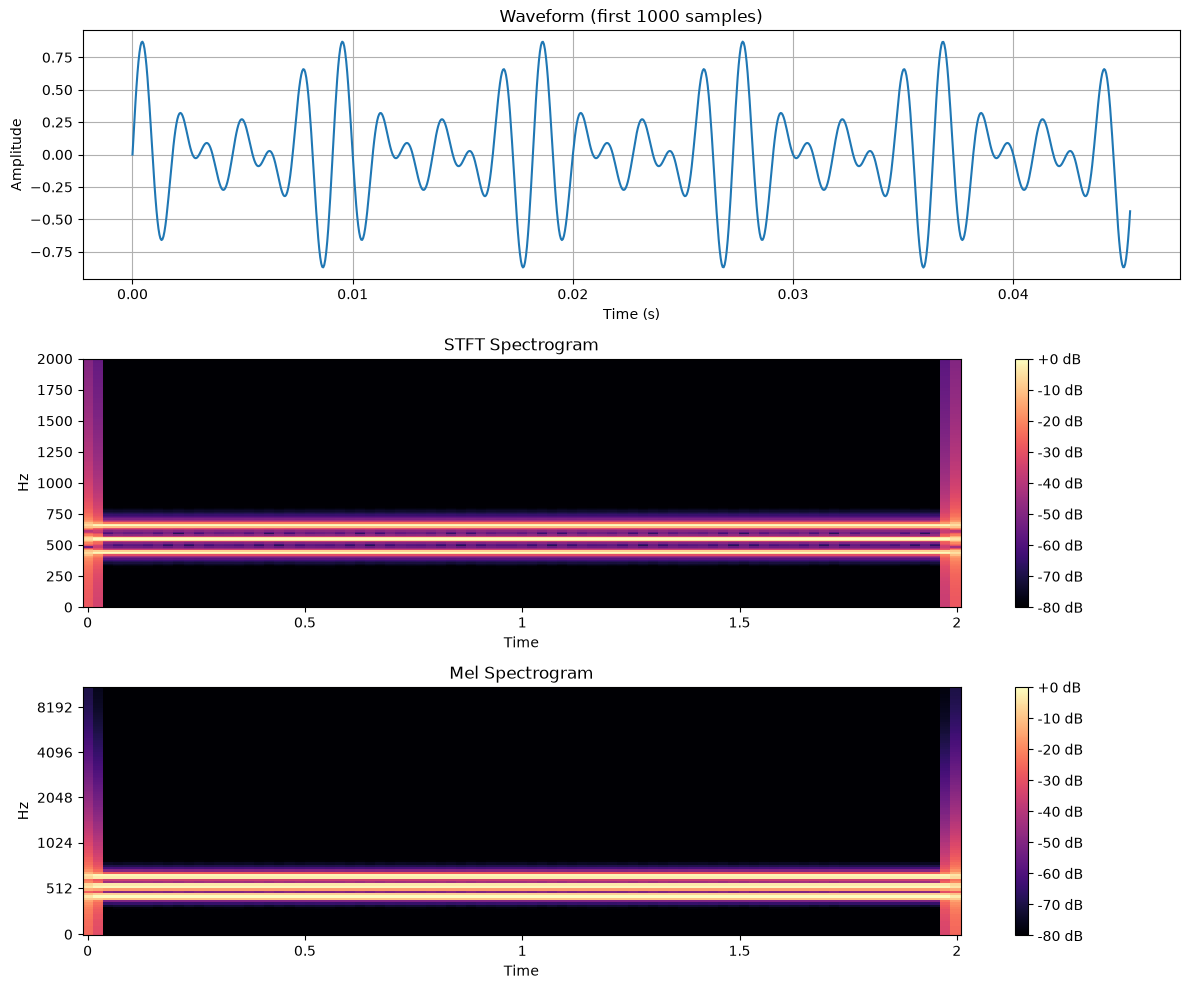

In [1]:
# Install: pip install librosa soundfile
import numpy as np
import matplotlib.pyplot as plt

try:
    import librosa
    import librosa.display
    
    # ============================================================
    # GENERATE SYNTHETIC AUDIO (sine wave)
    # ============================================================
    sr = 22050  # Sample rate
    duration = 2.0
    t = np.linspace(0, duration, int(sr * duration))
    
    # Chord: 440 Hz (A4) + 550 Hz + 660 Hz
    audio = 0.3 * np.sin(2 * np.pi * 440 * t) + \
            0.3 * np.sin(2 * np.pi * 550 * t) + \
            0.3 * np.sin(2 * np.pi * 660 * t)
    
    print(f"Audio shape: {audio.shape}")
    print(f"Sample rate: {sr} Hz")
    print(f"Duration: {len(audio)/sr:.2f} seconds")
    print(f"Value range: [{audio.min():.3f}, {audio.max():.3f}]")
    
    # Visualize waveform
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Waveform
    axes[0].plot(t[:1000], audio[:1000])
    axes[0].set_title('Waveform (first 1000 samples)')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True)
    
    # Spectrogram (STFT)
    D = librosa.stft(audio, n_fft=2048, hop_length=512)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=512,
                              x_axis='time', y_axis='hz', ax=axes[1])
    axes[1].set_title('STFT Spectrogram')
    axes[1].set_ylim(0, 2000)
    plt.colorbar(axes[1].collections[0], ax=axes[1], format='%+2.0f dB')
    
    # Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                              x_axis='time', y_axis='mel', ax=axes[2])
    axes[2].set_title('Mel Spectrogram')
    plt.colorbar(axes[2].collections[0], ax=axes[2], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install: pip install librosa")

MFCC shape: (13, 32) (13 coefficients × time frames)
Feature vector shape per frame: (39,)
Total frames: 32


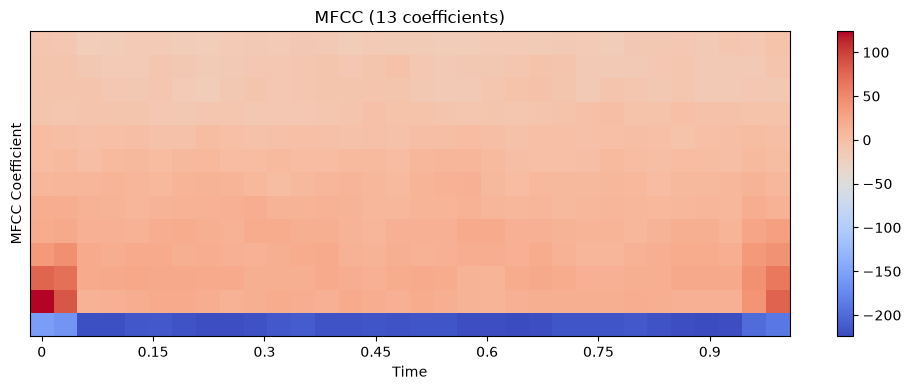


Mel filter bank shape: (40, 1025) (40 filters × FFT bins)


In [2]:
# ============================================================
# MFCC FEATURES
# ============================================================
try:
    import librosa
    import librosa.display
    import matplotlib.pyplot as plt
    
    # Create synthetic speech-like signal
    sr = 16000
    duration = 1.0
    t = np.linspace(0, duration, int(sr * duration))
    audio = np.sin(2 * np.pi * 200 * t) * np.exp(-t) + 0.01 * np.random.randn(len(t))
    
    # Extract features
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfccs)          # Velocity
    mfcc_delta2 = librosa.feature.delta(mfccs, order=2) # Acceleration
    
    # Stack features (common practice)
    features = np.vstack([mfccs, mfcc_delta, mfcc_delta2])  # 39-dim
    
    print(f"MFCC shape: {mfccs.shape} (13 coefficients × time frames)")
    print(f"Feature vector shape per frame: {features[:, 0].shape}")
    print(f"Total frames: {mfccs.shape[1]}")
    
    # Plot MFCCs
    fig, ax = plt.subplots(figsize=(10, 4))
    librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=ax)
    ax.set_title('MFCC (13 coefficients)')
    ax.set_ylabel('MFCC Coefficient')
    plt.colorbar(ax.collections[0], ax=ax)
    plt.tight_layout()
    plt.show()
    
    # Mel filter banks
    mel_filters = librosa.filters.mel(sr=sr, n_fft=2048, n_mels=40)
    print(f"\nMel filter bank shape: {mel_filters.shape} (40 filters × FFT bins)")
    
except ImportError:
    print("Install: pip install librosa")

In [3]:
# ============================================================
# SPEECH RECOGNITION WITH WHISPER
# ============================================================
print("OpenAI Whisper - Automatic Speech Recognition")
print("=" * 50)
print("""
# Install: pip install openai-whisper
import whisper

# Load model (sizes: tiny, base, small, medium, large, large-v3)
model = whisper.load_model('base')  # ~74M params

# Transcribe audio file
result = model.transcribe('audio.mp3')
print(result['text'])
print(result['language'])  # Detected language

# With timestamps
result = model.transcribe('audio.mp3', word_timestamps=True)
for segment in result['segments']:
    print(f"[{segment['start']:.2f}s - {segment['end']:.2f}s] {segment['text']}")

# Translate to English
result = model.transcribe('audio_french.mp3', task='translate')
""")

print()
print("Hugging Face Whisper (transformers):")
print("""
from transformers import pipeline

asr = pipeline(
    'automatic-speech-recognition',
    model='openai/whisper-base',
    chunk_length_s=30,
    return_timestamps=True
)

result = asr('audio.wav')
print(result['text'])
""")

OpenAI Whisper - Automatic Speech Recognition

# Install: pip install openai-whisper
import whisper

# Load model (sizes: tiny, base, small, medium, large, large-v3)
model = whisper.load_model('base')  # ~74M params

# Transcribe audio file
result = model.transcribe('audio.mp3')
print(result['text'])
print(result['language'])  # Detected language

# With timestamps
result = model.transcribe('audio.mp3', word_timestamps=True)
for segment in result['segments']:
    print(f"[{segment['start']:.2f}s - {segment['end']:.2f}s] {segment['text']}")

# Translate to English
result = model.transcribe('audio_french.mp3', task='translate')


Hugging Face Whisper (transformers):

from transformers import pipeline

asr = pipeline(
    'automatic-speech-recognition',
    model='openai/whisper-base',
    chunk_length_s=30,
    return_timestamps=True
)

result = asr('audio.wav')
print(result['text'])



In [4]:
# ============================================================
# FINE-TUNING WHISPER
# ============================================================
print("Fine-tuning Whisper for custom domain:")
print("""
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from datasets import load_dataset, Audio

# Load dataset (e.g., Common Voice)
dataset = load_dataset('mozilla-foundation/common_voice_11_0', 'ur', split='train')
dataset = dataset.cast_column('audio', Audio(sampling_rate=16000))

processor = WhisperProcessor.from_pretrained('openai/whisper-small')
model = WhisperForConditionalGeneration.from_pretrained('openai/whisper-small')

def prepare_dataset(batch):
    audio = batch['audio']
    batch['input_features'] = processor.feature_extractor(
        audio['array'], sampling_rate=audio['sampling_rate']
    ).input_features[0]
    batch['labels'] = processor.tokenizer(batch['sentence']).input_ids
    return batch

dataset = dataset.map(prepare_dataset)
# Then use Seq2SeqTrainer for fine-tuning...
""")

Fine-tuning Whisper for custom domain:

from transformers import WhisperProcessor, WhisperForConditionalGeneration
from datasets import load_dataset, Audio

# Load dataset (e.g., Common Voice)
dataset = load_dataset('mozilla-foundation/common_voice_11_0', 'ur', split='train')
dataset = dataset.cast_column('audio', Audio(sampling_rate=16000))

processor = WhisperProcessor.from_pretrained('openai/whisper-small')
model = WhisperForConditionalGeneration.from_pretrained('openai/whisper-small')

def prepare_dataset(batch):
    audio = batch['audio']
    batch['input_features'] = processor.feature_extractor(
        audio['array'], sampling_rate=audio['sampling_rate']
    ).input_features[0]
    batch['labels'] = processor.tokenizer(batch['sentence']).input_ids
    return batch

dataset = dataset.map(prepare_dataset)
# Then use Seq2SeqTrainer for fine-tuning...



In [5]:
# ============================================================
# TEXT-TO-SPEECH
# ============================================================
print("Text-to-Speech Options:")
print()
print("1. Coqui TTS (open-source):")
print("""
# pip install TTS
from TTS.api import TTS

tts = TTS('tts_models/en/ljspeech/tacotron2-DDC')
tts.tts_to_file('Hello, this is a test.', file_path='output.wav')

# Voice cloning with XTTS-v2
tts = TTS('tts_models/multilingual/multi-dataset/xtts_v2')
tts.tts_to_file(
    text='I am speaking in my cloned voice',
    speaker_wav='reference_speaker.wav',
    language='en',
    file_path='cloned_output.wav'
)
""")

print("2. Edge TTS (Microsoft, free):")
print("""
# pip install edge-tts
import edge_tts
import asyncio

async def speak(text, voice='en-US-AriaNeural', outfile='output.mp3'):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(outfile)

asyncio.run(speak('Hello from Microsoft Edge TTS!'))
""")

print("3. Hugging Face TTS models:")
print("""
from transformers import pipeline
synthesizer = pipeline('text-to-speech', model='microsoft/speecht5_tts')
speech = synthesizer('Hello, world!', forward_params={'speaker_embeddings': ...})
""")

Text-to-Speech Options:

1. Coqui TTS (open-source):

# pip install TTS
from TTS.api import TTS

tts = TTS('tts_models/en/ljspeech/tacotron2-DDC')
tts.tts_to_file('Hello, this is a test.', file_path='output.wav')

# Voice cloning with XTTS-v2
tts = TTS('tts_models/multilingual/multi-dataset/xtts_v2')
tts.tts_to_file(
    text='I am speaking in my cloned voice',
    speaker_wav='reference_speaker.wav',
    language='en',
    file_path='cloned_output.wav'
)

2. Edge TTS (Microsoft, free):

# pip install edge-tts
import edge_tts
import asyncio

async def speak(text, voice='en-US-AriaNeural', outfile='output.mp3'):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(outfile)

asyncio.run(speak('Hello from Microsoft Edge TTS!'))

3. Hugging Face TTS models:

from transformers import pipeline
synthesizer = pipeline('text-to-speech', model='microsoft/speecht5_tts')
speech = synthesizer('Hello, world!', forward_params={'speaker_embeddings': ...})



In [6]:
# ============================================================
# AUDIO CLASSIFICATION
# ============================================================
try:
    from transformers import pipeline
    import numpy as np
    
    # Audio classification (environmental sounds, music genres, etc.)
    print("Audio Classification with Wav2Vec2 / AST:")
    print("""
    # Audio Spectrogram Transformer
    from transformers import AutoFeatureExtractor, ASTForAudioClassification
    
    feature_extractor = AutoFeatureExtractor.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')
    model = ASTForAudioClassification.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')
    
    # Process audio
    inputs = feature_extractor(audio_array, sampling_rate=16000, return_tensors='pt')
    with torch.no_grad():
        logits = model(**inputs).logits
    predicted_class = logits.argmax(-1)
    label = model.config.id2label[predicted_class.item()]
    print(f'Predicted: {label}')
    """)

except Exception as e:
    print(f"Note: {e}")

Audio Classification with Wav2Vec2 / AST:

    # Audio Spectrogram Transformer
    from transformers import AutoFeatureExtractor, ASTForAudioClassification

    feature_extractor = AutoFeatureExtractor.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')
    model = ASTForAudioClassification.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')

    # Process audio
    inputs = feature_extractor(audio_array, sampling_rate=16000, return_tensors='pt')
    with torch.no_grad():
        logits = model(**inputs).logits
    predicted_class = logits.argmax(-1)
    label = model.config.id2label[predicted_class.item()]
    print(f'Predicted: {label}')
    


## Additional Learning Resources

### Papers
- [Whisper: Robust Speech Recognition via Large-Scale Weak Supervision](https://arxiv.org/abs/2212.04356) Radford et al., 2022
- [Wav2Vec 2.0: A Framework for Self-Supervised Learning of Speech Representations](https://arxiv.org/abs/2006.11477) Baevski et al., 2020
- [HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction](https://arxiv.org/abs/2106.07447)
- [VITS: Conditional Variational Autoencoder for TTS](https://arxiv.org/abs/2106.06103) Kim et al., 2021
- [Tacotron 2: Natural TTS Synthesis by Conditioning WaveNet](https://arxiv.org/abs/1712.05884) Shen et al., 2018
- [CTC: Connectionist Temporal Classification](https://dl.acm.org/doi/10.1145/1143844.1143891) Graves et al., 2006

### Libraries
- [librosa](https://librosa.org/) Audio analysis library for Python
- [OpenAI Whisper](https://github.com/openai/whisper) State-of-the-art ASR
- [Coqui TTS](https://github.com/coqui-ai/TTS) Open-source TTS with voice cloning
- [pyAudioAnalysis](https://github.com/tyiannak/pyAudioAnalysis) Audio feature extraction
- [pyannote-audio](https://github.com/pyannote/pyannote-audio) Speaker diarization

### Courses
- [Hugging Face Audio Course](https://huggingface.co/learn/audio-course/) Free, comprehensive
- [Deep Learning for Audio](https://www.youtube.com/watch?v=fMqL5vckiU0) Valerio Velardo's YouTube series
- [Stanford CS224S: Spoken Language Processing](https://web.stanford.edu/class/cs224s/)